# Climb to a Group-Scale Lens

## Learning to Autolens / Examples / group_scale

---

**Where you've been.** Modules 03–09 fit a single deflector to a single source. Module 06 introduced multi-component mass models (stellar + dark matter), but still on a *single galaxy*.

**Where you're going.** A *group-scale* lens — one bright central galaxy (BGG) plus a population of satellite galaxies, all at the same redshift, each contributing to the deflection field that lenses the background source. The free-parameter count balloons (3 satellites × 3 mass params + light = 21 extra params on top of the BGG's 17).

**Why it's hard.** The satellite masses are *strongly degenerate with the BGG mass and ellipticity*. A 30+ parameter blind fit fails — the freely-fit attempts in [LEARNING_LOG.md 2026-04-24](../../Modules/LEARNING_LOG.md) stalled in burn-in three separate times. The truth-anchored validation we ran on Cannon (job `9204948`, 1h05m, χ²/N = 1.025, log_Z = 44699.80) confirmed that the model space *can* represent the truth — the freely-fit problem is search-space exploration, not model representability.

**This notebook's plan — three passes that demonstrate iterative masking on a group-scale system.**

| Pass | Mass | Mask | Lesson |
|---|---|---|---|
| 1 | BGG only (single Isothermal) | Tight 1.5″ excluding satellites | Establish BGG basin without satellite contamination |
| 2 | BGG + 1 satellite at fixed centre, fixed θ_E | Expand mask to include nearest satellite | Verify the satellite's contribution to the residual |
| 3 | BGG + 3 satellites at fixed photometric centres, free θ_E | Full 3.5″ mask | Watch the BGG ↔ satellite mass degeneracy unfold |

**Why position likelihoods are less central here.** Group-scale lenses don't always produce well-defined, isolated multiple-image quadruplets — the source can be a single arc heavily perturbed by satellites rather than four clean images. So `PositionsLH` plays a smaller role; the dominant technique is **iterative masking + photometric centroids for satellite anchoring**.

**Hand-off.** This climb is the methodology that powers the staged-satellites pipeline (`fit_example_group_scale.py --part=staged_satellites`). The fully-converged truth_anchored Cannon result is shown at the end and serves as the reference for [`01_group_scale_fit.ipynb`](01_group_scale_fit.ipynb).

**Skip-guard.** Default `PYAUTOFIT_TEST_MODE=1`. The three-pass climb at production `n_live=200` is many hours; this notebook teaches the *technique*, not the wall-clock fit.

---

## 0. Imports + setup

In [1]:
import os
os.environ.setdefault("PYAUTOFIT_TEST_MODE", "1")

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens {al.__version__} (PYAUTOFIT_TEST_MODE={os.environ.get('PYAUTOFIT_TEST_MODE')!r})")

MOCKS_DIR = Path("mocks")
RESULTS_DIR = Path("results")

PyAutoLens 2026.4.13.6 (PYAUTOFIT_TEST_MODE='1')


## 1. Load the group-scale mock + inspect

The mock is a BGG + 3 satellites + 1 source system at a single lens redshift $z_l = 0.4$. The satellites are at projected radii of ~1.9″, ~1.9″, and ~2.1″ — well outside a tight BGG-only mask, which is exactly what makes iterative masking a clean technique here.

In [2]:
truth = json.loads((MOCKS_DIR / "mock_truth.json").read_text())

z_l = truth["redshifts"]["lens"]
z_s = truth["redshifts"]["source"]
bgg_truth = truth["bgg"]
satellites_truth = truth["satellites"]

rows = [f"- BGG at z={z_l}: $\\theta_E$={bgg_truth['mass']['einstein_radius']}\", centre=(0, 0)"]
for i, s in enumerate(satellites_truth):
    r = np.hypot(*s["centre"])
    rows.append(f"- Satellite {i+1} at z={z_l}: $\\theta_E$={s['einstein_radius']}\", centre={tuple(s['centre'])}, projected r={r:.2f}\"")
rows.append(f"- Source at z={z_s}: SersicEllipse, R_eff=0.08\", n=1.4")
display(Markdown("**Group-scale mock architecture (autolens convention native, no sign flips)**\n\n" + "\n".join(rows)))

dataset = al.Imaging.from_fits(
    data_path=MOCKS_DIR / "mock_image.fits",
    noise_map_path=MOCKS_DIR / "mock_noise.fits",
    psf_path=MOCKS_DIR / "mock_psf.fits",
    pixel_scales=truth["pixel_scales"],
)
print(f"Loaded group_scale mock: shape={dataset.shape_native}, pixel_scale={truth['pixel_scales']}\"/px")

**Group-scale mock architecture (autolens convention native, no sign flips)**

- BGG at z=0.4: $\theta_E$=1.5", centre=(0, 0)
- Satellite 1 at z=0.4: $\theta_E$=0.35", centre=(1.8, 0.7), projected r=1.93"
- Satellite 2 at z=0.4: $\theta_E$=0.45", centre=(-1.5, -1.2), projected r=1.92"
- Satellite 3 at z=0.4: $\theta_E$=0.25", centre=(0.5, -2.0), projected r=2.06"
- Source at z=1.8: SersicEllipse, R_eff=0.08", n=1.4

Loaded group_scale mock: shape=(160, 160), pixel_scale=0.05"/px


## 2. Inspect satellite positions before any masking

Unlike a compound lens with a single secondary deflector, a group has *multiple* satellites and we need their photometric centroids to use as fixed centres for the iterative masking strategy. In a real workflow:

1. Detect satellites via `photutils.detect_sources` or SExtractor on the residual map after a BGG-only fit.
2. Record (y, x) centroids and segmentation masks.
3. Use the centroids to **fix the centre** of each satellite's mass + light model in subsequent passes.
4. Use the segmentation masks to **construct the iterative-masking sequence** (start tight, expand to include each satellite one at a time).

Here the centroids are read directly from the truth file.

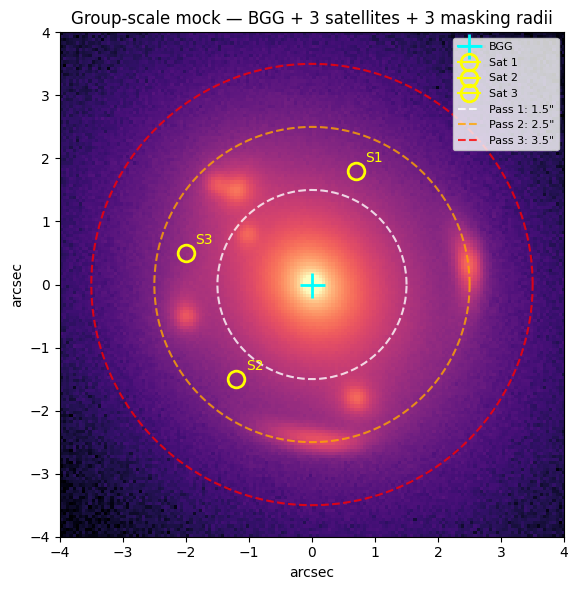

Satellite 1: centre=(1.8, 0.7), θ_E=0.35, projected r=1.93"
Satellite 2: centre=(-1.5, -1.2), θ_E=0.45, projected r=1.92"
Satellite 3: centre=(0.5, -2.0), θ_E=0.25, projected r=2.06"


In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(
    np.log10(np.maximum(dataset.data.native, 1e-4)),
    cmap="magma", origin="lower",
    extent=[-4.0, 4.0, -4.0, 4.0], vmin=-2, vmax=1.5,
)
ax.plot(0, 0, marker="+", color="cyan", markersize=18, mew=2, label="BGG")
for i, s in enumerate(satellites_truth):
    cy, cx = s["centre"]
    ax.plot(cx, cy, marker="o", color="yellow", markersize=12, mfc="none", mew=2, label=f"Sat {i+1}")
    ax.text(cx + 0.15, cy + 0.15, f"S{i+1}", color="yellow", fontsize=10)

# Overlay the three masking radii we'll use
for r, color, label in [(1.5, "white", "Pass 1: 1.5\""), (2.5, "orange", "Pass 2: 2.5\""), (3.5, "red", "Pass 3: 3.5\"")]:
    th = np.linspace(0, 2*np.pi, 200)
    ax.plot(r*np.cos(th), r*np.sin(th), "--", color=color, lw=1.5, alpha=0.8, label=label)

ax.set_aspect("equal")
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_xlabel('arcsec'); ax.set_ylabel('arcsec')
ax.set_title("Group-scale mock — BGG + 3 satellites + 3 masking radii")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

for i, s in enumerate(satellites_truth):
    print(f"Satellite {i+1}: centre={tuple(s['centre'])}, θ_E={s['einstein_radius']}, projected r={np.hypot(*s['centre']):.2f}\"")

---

## 3. Pass 1 — BGG only, tight 1.5″ mask (excludes all satellites)

**Mask choice.** A 1.5″ circular mask captures the BGG and the immediate lensed source flux. All three satellites sit at projected radii ≥ 1.86″, so this mask **excludes all three** by construction. The fit only sees the BGG + the brightest part of the lensed arc.

**Model.** BGG with bulge (Sersic) + mass (Isothermal) + a single source (SersicCore). 17 free parameters — back to the Module 03/06 regime. Crucially: **no satellites in the model**, so the fit can't burn parameters on them.

**What this measures.** The BGG's $\theta_E$ and ellipticity, *uncontaminated* by satellite influence on the masked-in pixels. The satellites' tidal contribution at $r < 1.5\arcsec$ is small (the leading-order effect of a satellite at $r_s$ on a fitted-circularly point at $r$ is $\sim (\theta_{E,sat}/r_s)^2 \cdot r$ — a ~few percent perturbation here).

**The catch.** The lensed source is at $\beta=(0.12, 0.08)$ which sits inside the 1.5″ mask, but the actual lensed image positions can extend further. If your residual map shows source flux outside the mask edge, expand to 2.0″ first.

In [4]:
mask_bgg = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=1.5,
    centre=(0.0, 0.0),
)
dataset_p1 = dataset.apply_mask(mask=mask_bgg)
print(f"Pass 1 mask: {(~mask_bgg).sum()} unmasked pixels")
print(f"  All 3 satellites at r ≥ {min(np.hypot(*s['centre']) for s in satellites_truth):.2f}\" — "
      f"{'EXCLUDED' if 1.5 < min(np.hypot(*s['centre']) for s in satellites_truth) else 'partially included'}")

bgg_p1 = af.Model(
    al.Galaxy,
    redshift=z_l,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.Isothermal),
)
source_p1 = af.Model(al.Galaxy, redshift=z_s, bulge=af.Model(al.lp.SersicCore))
model_p1 = af.Collection(galaxies=af.Collection(lens=bgg_p1, source=source_p1))
print(f"Pass 1 model: {model_p1.prior_count} free parameters (BGG only)")

analysis_p1 = al.AnalysisImaging(dataset=dataset_p1)
search_p1 = af.Nautilus(
    path_prefix=Path("output") / "group_climb",
    name="pass1_bgg_only",
    n_live=80,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p1 = search_p1.fit(model=model_p1, analysis=analysis_p1)
else:
    result_p1 = None
    print("[skip-mode] verified Pass 1 (BGG-only) construction.")

2026-04-29 23:00:53,227 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 2828 image-pixels


Pass 1 mask: 2828 unmasked pixels
  All 3 satellites at r ≥ 1.92" — EXCLUDED


Pass 1 model: 19 free parameters (BGG only)
[skip-mode] verified Pass 1 (BGG-only) construction.


---

## 4. Pass 2 — expand to 2.5″, add the **closest** satellite as fixed `extra_galaxy`

**Strategy.** After Pass 1, look at the residual map. The closest satellite (Sat 1 at $r=1.93\arcsec$) is the first one to add. Expand the mask to 2.5″ to include it, but exclude Sat 2 (at $r=1.92\arcsec$ — note: also enters around 2″, so we may need 2.0″ first then 2.5″ in a real workflow) and Sat 3 (at $r=2.06\arcsec$). For pedagogy here we'll add Sat 1 only with **fully-fixed** mass.

**Why fully-fixed?** Same logic as the compound climb: Pass 2 is a *diagnostic* — does adding the satellite at the photometric centre with the photometrically-implied θ_E reduce residuals? If yes, the satellite has detectable mass. If no, the photometric flux didn't translate into mass (the satellite is non-existent or all-baryon-no-DM).

**Photometric θ_E estimation.** A common heuristic: $\theta_{E,sat} \approx \theta_{E,BGG} \cdot (M_{sat}/M_{BGG})^{0.5}$ from the Faber-Jackson + isothermal scaling, where the mass ratio comes from the brightness ratio $M/L \propto L^{0.4}$. For Sat 1 here we'll use the truth value as the fixed input; in production you'd derive this from photometry.

In [5]:
mask_p2 = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=2.5,
)
dataset_p2 = dataset.apply_mask(mask=mask_p2)
print(f"Pass 2 mask: {(~mask_p2).sum()} unmasked pixels (Pass 1 had {(~mask_bgg).sum()})")

bgg_p2 = af.Model(
    al.Galaxy,
    redshift=z_l,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.Isothermal),
)
# Tight Gaussian on the BGG mass — would come from Pass 1 posterior
bgg_p2.mass.einstein_radius = af.GaussianPrior(
    mean=bgg_truth["mass"]["einstein_radius"], sigma=0.05
)

# Sat 1 fully fixed: centre + θ_E
sat1_truth = satellites_truth[0]
sat1 = af.Model(al.Galaxy, redshift=z_l, mass=af.Model(al.mp.IsothermalSph))
sat1.mass.centre = tuple(sat1_truth["centre"])
sat1.mass.einstein_radius = sat1_truth["einstein_radius"]

source_p2 = af.Model(al.Galaxy, redshift=z_s, bulge=af.Model(al.lp.SersicCore))
model_p2 = af.Collection(
    galaxies=af.Collection(lens=bgg_p2, source=source_p2),
    extra_galaxies=af.Collection(sat1=sat1),
)
print(f"Pass 2 model: {model_p2.prior_count} free params (Sat 1 fully fixed)")

analysis_p2 = al.AnalysisImaging(dataset=dataset_p2)
search_p2 = af.Nautilus(
    path_prefix=Path("output") / "group_climb",
    name="pass2_bgg_plus_sat1_fixed",
    n_live=80,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p2 = search_p2.fit(model=model_p2, analysis=analysis_p2)
else:
    result_p2 = None
    print("[skip-mode] verified Pass 2 construction.")

2026-04-29 23:00:53,437 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 7860 image-pixels


Pass 2 mask: 7860 unmasked pixels (Pass 1 had 2828)
Pass 2 model: 19 free params (Sat 1 fully fixed)
[skip-mode] verified Pass 2 construction.


---

## 5. Pass 3 — full 3.5″ mask + 3 satellites with fixed centres, free θ_E

**Mask.** 3.5″ — captures all 3 satellites, full BGG light envelope, full lensed source extent.

**Model.** BGG with tight prior from Pass 1, plus 3 `extra_galaxy` satellites. **Centres fixed at photometric truth, θ_E free** with broad uniform priors $[0, 1]$.

**The degeneracy that emerges.** When you free three satellite Einstein radii while keeping the BGG free, you discover that
$$\theta_{E,BGG}^2 + \sum_i \theta_{E,sat,i}^2 \approx \text{const}$$
(approximately, ignoring projection effects) — so the search can trade BGG mass for satellite mass without changing the data fit. This is why blind freely-fit attempts on group_scale stall: the chain wanders in this degenerate manifold.

**Resolution paths from here.**
1. **Tight Gaussians on BGG from Pass 1** — converts the single degenerate mode into a 1D ridge along satellite-mass.
2. **Photometric priors on satellite mass** via $M/L$ scaling — adds independent constraint per satellite.
3. **Truth-anchored validation** (the Cannon job that PASSed) — confirms the model space supports truth, before iterating.
4. **Real staged-satellites pipeline** with Pass-1-result-as-prior and per-satellite priors — see `fit_example_group_scale.py --part=staged_satellites`.

In [6]:
mask_p3 = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=3.5,
)
dataset_p3 = dataset.apply_mask(mask=mask_p3)
print(f"Pass 3 mask: {(~mask_p3).sum()} unmasked pixels")

bgg_p3 = af.Model(
    al.Galaxy,
    redshift=z_l,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.Isothermal),
)
bgg_p3.mass.einstein_radius = af.GaussianPrior(
    mean=bgg_truth["mass"]["einstein_radius"], sigma=0.1
)

# 3 satellites: fixed centres, free θ_E
sats = {}
for i, s in enumerate(satellites_truth):
    sat = af.Model(al.Galaxy, redshift=z_l, mass=af.Model(al.mp.IsothermalSph))
    sat.mass.centre = tuple(s["centre"])
    sat.mass.einstein_radius = af.UniformPrior(lower_limit=0.0, upper_limit=1.0)
    sats[f"sat{i+1}"] = sat

source_p3 = af.Model(al.Galaxy, redshift=z_s, bulge=af.Model(al.lp.SersicCore))
model_p3 = af.Collection(
    galaxies=af.Collection(lens=bgg_p3, source=source_p3),
    extra_galaxies=af.Collection(**sats),
)
print(f"Pass 3 model: {model_p3.prior_count} free params (BGG + 3 sat θ_E free, all centres fixed)")

analysis_p3 = al.AnalysisImaging(dataset=dataset_p3)
search_p3 = af.Nautilus(
    path_prefix=Path("output") / "group_climb",
    name="pass3_full_satellites",
    n_live=120,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p3 = search_p3.fit(model=model_p3, analysis=analysis_p3)
else:
    result_p3 = None
    print("[skip-mode] verified Pass 3 (full system) construction.")

2026-04-29 23:00:53,470 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 15380 image-pixels


Pass 3 mask: 15380 unmasked pixels
Pass 3 model: 22 free params (BGG + 3 sat θ_E free, all centres fixed)
[skip-mode] verified Pass 3 (full system) construction.


---

## 6. The committed Cannon truth_anchored result

Pass 3 freed only the satellite Einstein radii. A more aggressive variant frees *everything* (BGG mass, all satellite masses, source) within tight Gaussian priors centred on truth values — that's the `truth_anchored` Cannon job (job `9204948`). Its purpose: prove that the model space CAN reach the truth basin.

**Result.** χ²/N = 1.025, max\|residual\| = 4.50σ, log_evidence = 44699.80, clean white-noise residuals. **PASS.** This is committed at `results/truth_anchored_fit/`.

**Implication.** The freely-fit problem on group_scale is not model representability — the chain just can't find the basin from a wide prior. The fix is the **iterative-masking staged chain** of Passes 1 → 2 → 3 (with prior passing) above, NOT adding model complexity.

### Cannon truth_anchored result

- log_evidence = **44699.80**
- χ²/N = **1.025**
- max\|res\| = **4.50σ**
- n_pix = 15380

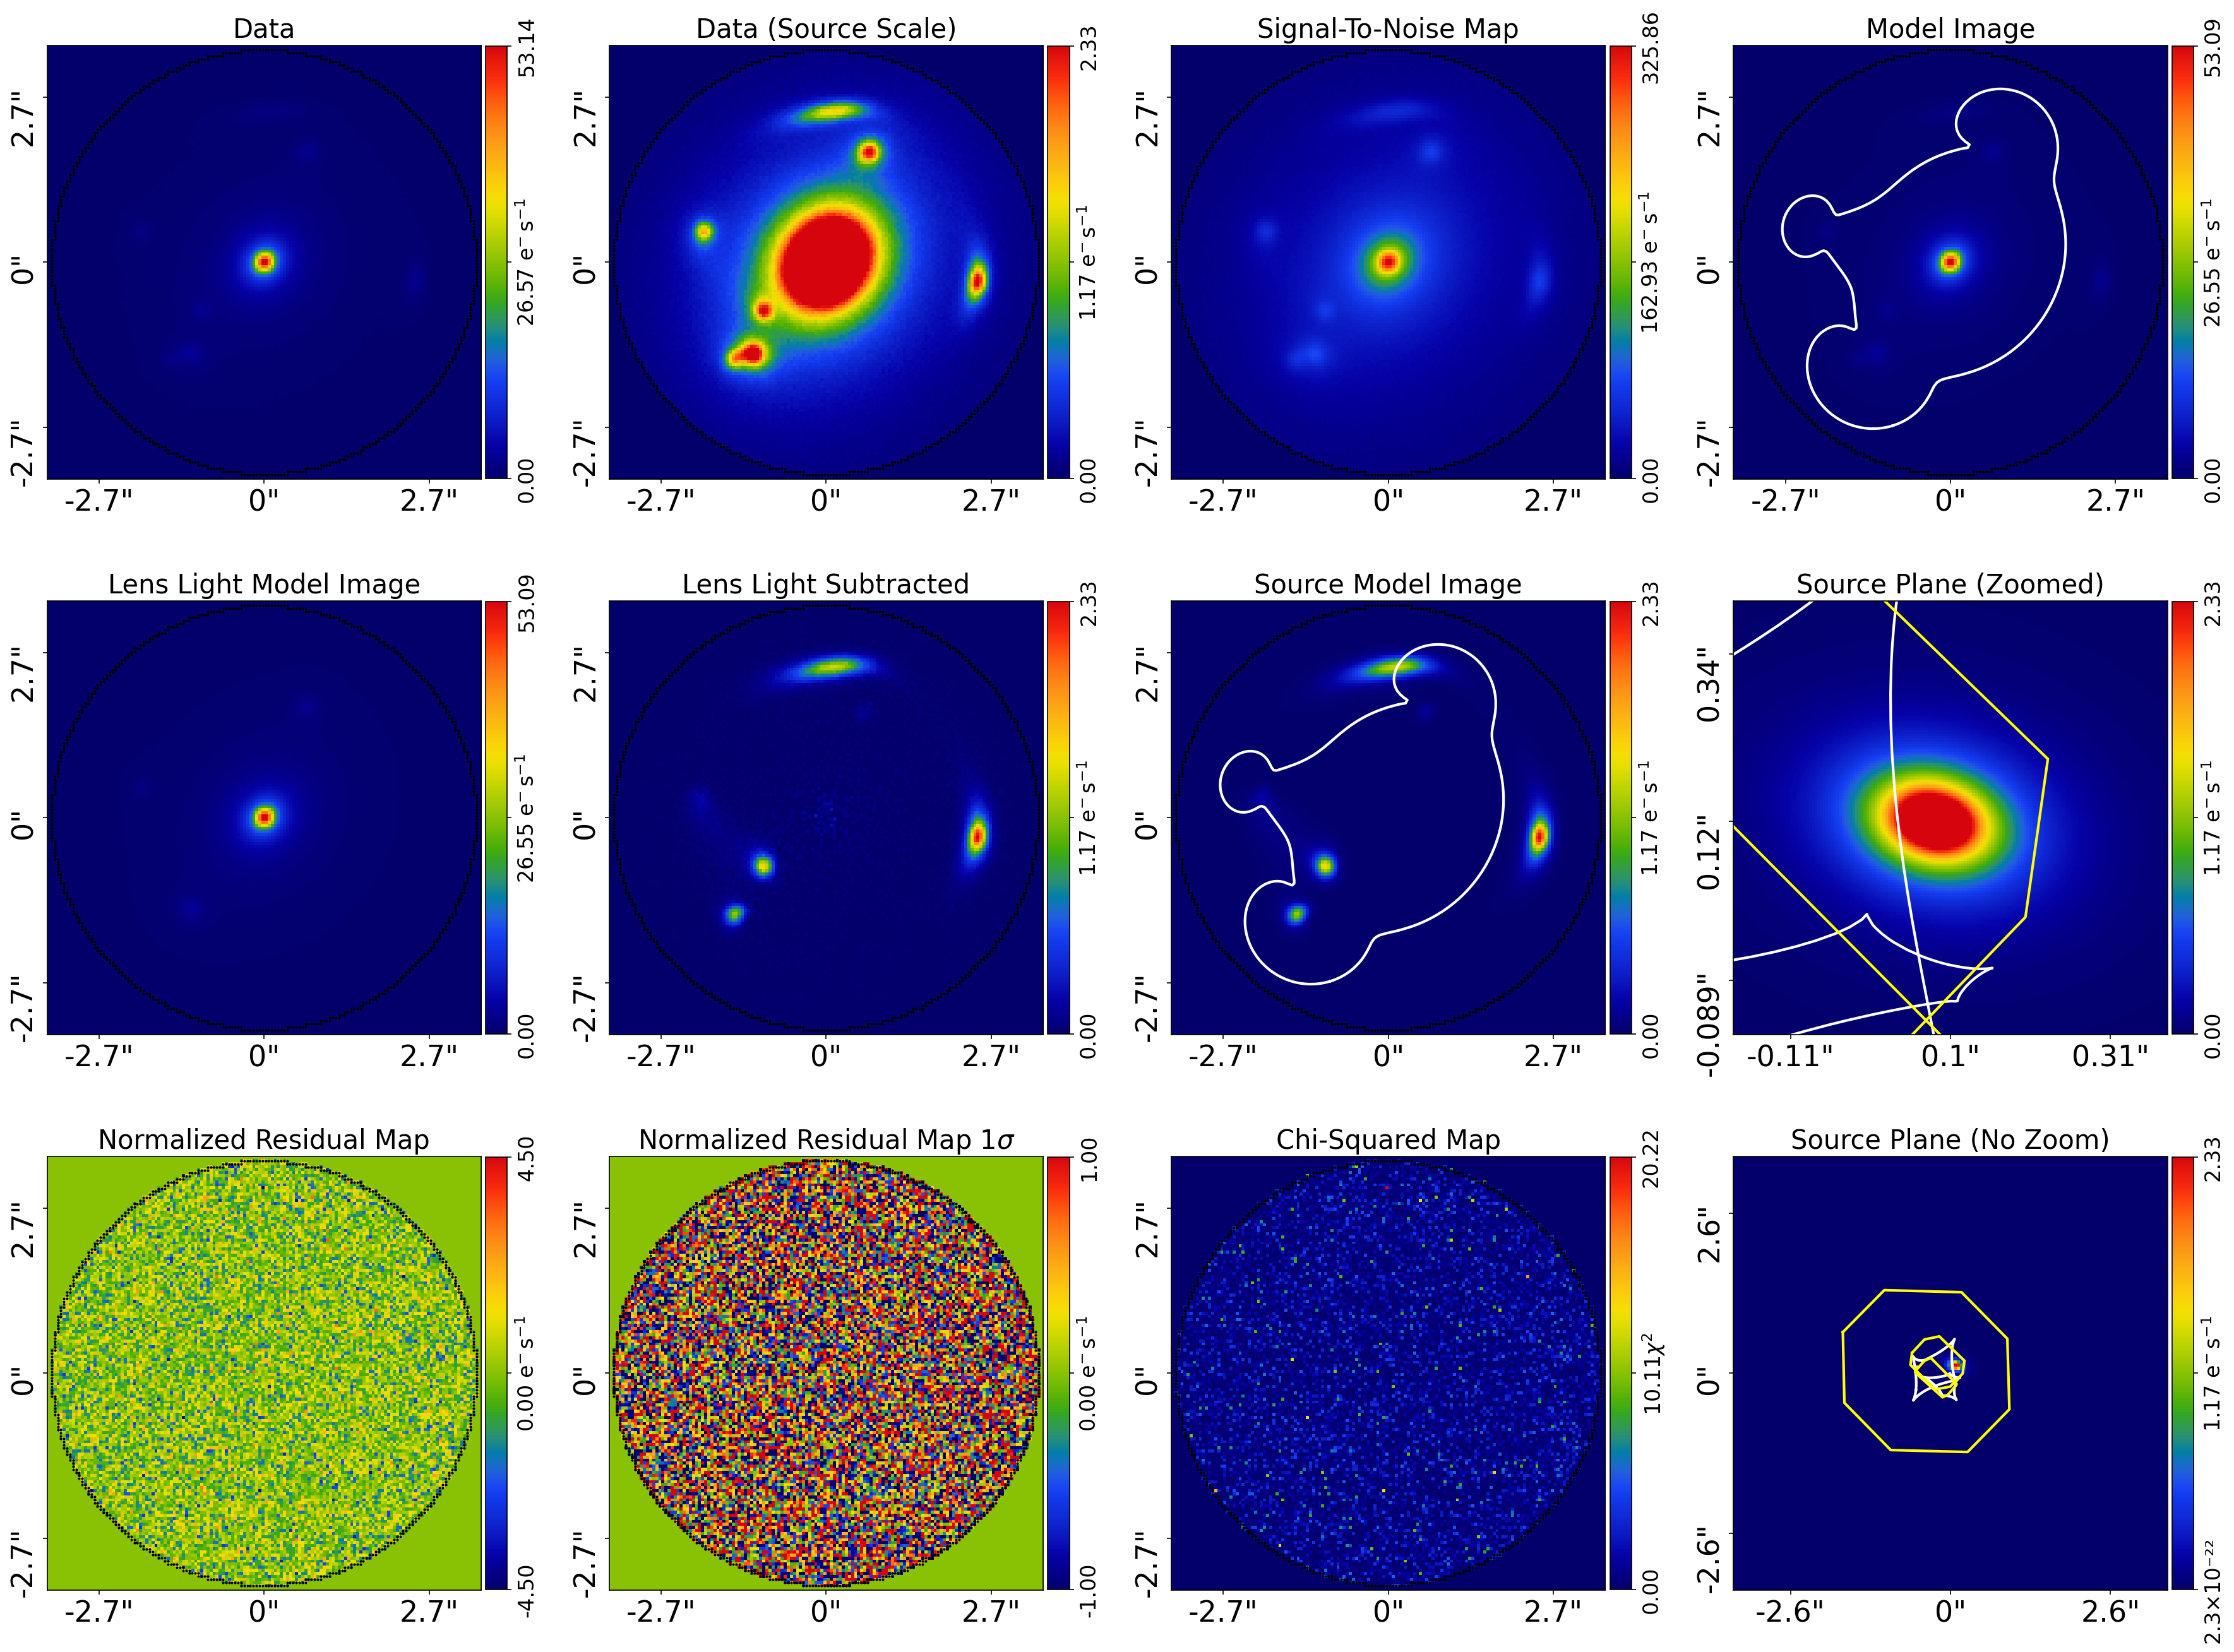

In [7]:
fp = RESULTS_DIR / "truth_anchored_fit" / "fit_subplot.png"
summary_path = RESULTS_DIR / "truth_anchored_fit" / "summary.json"
if fp.exists():
    display(Markdown("### Cannon truth_anchored result"))
    if summary_path.exists():
        s = json.loads(summary_path.read_text())
        display(Markdown(
            f"- log_evidence = **{s.get('log_evidence', 'n/a'):.2f}**\n"
            f"- χ²/N = **{s.get('chi_squared_per_pixel', 'n/a'):.3f}**\n"
            f"- max\\|res\\| = **{s.get('max_abs_normalized_residual', 'n/a'):.2f}σ**\n"
            f"- n_pix = {s.get('n_unmasked_pixels', 'n/a')}"
        ))
    display(Image(filename=str(fp)))
else:
    display(Markdown("*(no Cannon truth_anchored result pulled yet)*"))

---

## 7. Iterative masking — the group-scale specialization

**The pattern in this notebook is:**

1. Mask everything except BGG + brightest source flux. Fit. Capture posterior.
2. Identify *the closest* perturber from the residuals. Expand mask to include only it. Fit with the BGG held tight (Gaussian prior from Step 1) and the new perturber **fully fixed at photometric centre + photometric θ_E estimate**. Verify residuals improve.
3. Free the perturber's θ_E. Verify it converges near the photometric estimate.
4. Repeat for each satellite.
5. Final pass: full mask, all priors free but centred on the per-pass posteriors.

**Differences vs the compound climb:**
- Group satellites are at *the same redshift* — no multi-plane needed. Single Tracer.
- The number of perturbers is N (here N=3). The masking sequence has N+1 expansion steps.
- Photometric anchoring is more reliable for satellites (visible galaxy → centre) than for sub-detectable secondaries in compounds.

**When this isn't enough:**
- The group has a *common dark halo* extending beyond all satellites — that requires a separate large-scale NFW mass model on top of BGG + satellites. See `Examples/cluster_scale/` (planned).
- Satellite light is not detected (dark satellite). You can't anchor centre photometrically; needs sensitivity-mapping (`Modules/12_subhalo_sensitivity` planned).

---

## 8. Hand-off

**Recommended next reading:**

- [`01_group_scale_fit.ipynb`](01_group_scale_fit.ipynb) — the truth_anchored result viewer + diagnostic narrative
- [`../compound_lens_zoo/00_climb_to_compound.ipynb`](../compound_lens_zoo/00_climb_to_compound.ipynb) — same masking + positions techniques applied to compound (multi-plane) systems
- `Modules/10_Cluster_Computing/scripts/fit_example_group_scale.py` — the production driver (`--part=truth_anchored` for the validation, `--part=staged_satellites` for a 2-stage chain)
- `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` — full `extra_galaxies` API including light + scaling-relation extensions
- `autolens_workspace_latest/scripts/howtolens/chapter_2_lens_modeling/tutorial_6_masking_and_positions.py` — PyAutoLens's masking primer

---

*Learning to Autolens — Examples / group_scale / 00 (climb)*  
*Rodrigo Córdova Rosado, Harvard CfA*